In [1]:
from functools import partial
import math

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

First we load the MNIST dataset.

In [2]:
def load_data():
    train_ds = MNIST('data', train=True, transform=ToTensor(), download=True)
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    return train_dl

Second, we create a 5-layer ReLU MLP. We set the bias to `false` to prevent exploding gradients. We also write a custom initialization function.

In [3]:
num_layers = 5

In [4]:
class MLP(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.Sequential()
        self.activation = activation
        for i in range(num_layers-1):
            self.layers.add_module(f"Dense {i+1}", nn.LazyLinear(64, bias=False))
            if activation:
                self.layers.add_module(f"Activation {i+1}", activation())
        self.layers.add_module(f"Dense {num_layers})", nn.LazyLinear(10, bias=False))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)

In [5]:
def custom_init(gain, m):
    if isinstance(m, nn.Linear):
        std = gain * math.sqrt(2 / m.weight.shape[1]) # He init
        nn.init.normal_(m.weight, std=std)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def apply_init(model, gain):
    model(torch.zeros(1, 784)) # initialize lazy layers
    init_fn = partial(custom_init, gain)
    model.apply(init_fn)

In [6]:
def mean(lst):
    return sum(lst) / len(lst)

def append(lst1, lst2, elem1, elem2):
    lst1.append(elem1)
    lst2.append(elem2)

In [7]:
def stats(model, X, y):
    logits = model(X)
    loss = F.cross_entropy(logits, y)
    accuracy = (logits.argmax(dim=1) == y).float().mean()
    return loss, accuracy

def train_step(opt, model, X, y):
    loss, accuracy = stats(model, X, y)
    loss.backward()
    opt.step()
    return loss.item(), accuracy.item()

In [8]:
def get_grads(model):
    w, wg = [], []
    for m in model.modules():
        if isinstance(m, nn.Linear):
            w.append(m.weight.std())
            wg.append(m.weight.grad.std())
    return w, wg

def get_activations(model, x):
    pacts, acts = [], []
    x = torch.flatten(x, start_dim=1)
    for i in range(num_layers):
        if model.activation:
            assert isinstance(model.layers[i*2], nn.Linear)
            x = model.layers[i*2](x) # linear
            pacts.append(x.std())
            if i != num_layers-1:
                assert not isinstance(model.layers[i*2+1], nn.Linear)
                x = model.layers[i*2+1](x) # activation function
            acts.append(x.std())
        else:
            x = model.layers[i](x)
            pacts.append(x.std())
            acts.append(x.std())
    return pacts, acts

In [9]:
def train_model(activation=nn.ReLU, gain=1, num_epochs = 1, lr=0.05):
    torch.manual_seed(0)
    train_dl = load_data()
    model = MLP(activation=activation)
    apply_init(model, gain=gain)
    opt = torch.optim.SGD(model.parameters(), lr)
    ls, accs, acts, pacts, ws, wgs = [], [], [], [], [], []
    for _ in range(num_epochs):
        for i, (X, y) in enumerate(train_dl):
            with torch.no_grad():
                pact, act = get_activations(model, X)
            loss, acc = train_step(opt, model, X, y)
            w, wg = get_grads(model)
            append(ls, accs, loss, acc)
            append(pacts, acts, pact, act)
            append(ws, wgs, w, wg)
            opt.zero_grad()
    pacts = torch.tensor(pacts).transpose(0, 1)
    acts = torch.tensor(acts).transpose(0, 1)
    ws = torch.tensor(ws).transpose(0, 1)
    wgs = torch.tensor(wgs).transpose(0, 1)             
    return ls, accs, pacts, acts, ws, wgs

In [10]:
def plot_experiments(linear_stats, relu_stats, tanh_stats, sigmoid_stats, gain,
                     n_plot_linear=-1, n_plot_relu=-1, n_plot_tanh=-1, 
                     n_plot_sigmoid=-1):
    nrows = 4
    ncols = 6
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6.5))

    def plot_column(losses, accuracies, pact, act, w, wg, i, n_plot):
        if isinstance(n_plot, (tuple, list)):
            slc = slice(*n_plot)
        else:
            slc = slice(0, n_plot)
        axs[i, 0].plot(losses[slc])
        axs[i, 1].plot(accuracies[slc])
        for j in range(wg.shape[0]):
            label = f"{j}" if i == 0 else None
            axs[i, 2].plot(pact[j, slc], label=label)
            axs[i, 3].plot(act[j, slc])
            axs[i, 4].plot(w[j, slc])
            axs[i, 5].plot(wg[j, slc])
        for j in range(ncols):
            if isinstance(n_plot, (tuple, list)):
                axs[i, j].set_xlim([*n_plot])
            else:
                if n_plot != -1:
                    axs[i, j].set_xlim([0,n_plot])
            

    def set_yaxes():
        for i in range(nrows):
            axs[i, 0].set_yscale('log')
            axs[i, 1].set_ylim([0.0, 1.0])
            axs[i, 1].set_yticks([0.0, 1.0])
            axs[i, 2].set_yscale('log')
            axs[i, 3].set_yscale('log')
            axs[i, 4].set_yscale('log')
            axs[i, 5].set_yscale('log')

    def remove_xticks():
        for i in range(nrows):
            for j in range(ncols):
                axs[i, j].set_xticks([])

    def label_activations():
        axs[0, 0].set_ylabel("Linear", fontsize=14)
        axs[1, 0].set_ylabel("ReLU", fontsize=14)
        axs[2, 0].set_ylabel("Tanh", fontsize=14)
        axs[3, 0].set_ylabel("Sigmoid", fontsize=14)

    def label_stats():
        axs[0, 0].set_title('Losses', fontsize=12)
        axs[0, 1].set_title('Accuracies', fontsize=12)
        axs[0, 2].set_title('Pre-Activation\nstddev', fontsize=12)
        axs[0, 3].set_title('Activation stddev', fontsize=12)
        axs[0, 4].set_title('Weight stddev', fontsize=12)
        axs[0, 5].set_title("Gradient stddev", fontsize=12)

    def set_legend():
        fig.legend(title="Layer", fontsize=8, ncol=num_layers)
    
    def set_title():
        fig.suptitle(f"Gain factor: {gain}", fontsize=16)

    plot_column(*linear_stats, 0, n_plot_linear)
    plot_column(*relu_stats, 1, n_plot_relu)
    plot_column(*tanh_stats, 2, n_plot_tanh)
    plot_column(*sigmoid_stats, 3, n_plot_sigmoid)

    set_yaxes()
    remove_xticks()
    label_activations()
    label_stats()
    set_legend()
    set_title()

    fig.tight_layout()

# Experiment #1: Gain factor 0.1

In [11]:
gain_small = 0.1
lr = 0.005 * (gain_small)**(-(num_layers - 2))
num_epochs = 1

linear_stats_small = train_model(activation=None, gain=gain_small, num_epochs=num_epochs, lr=lr)
relu_stats_small = train_model(activation=nn.ReLU, gain=gain_small, num_epochs=num_epochs, lr=lr)
tanh_stats_small = train_model(activation=nn.Tanh, gain=gain_small, num_epochs=num_epochs, lr=lr)
sigmoid_stats_small = train_model(activation=nn.Sigmoid, gain=gain_small, num_epochs=num_epochs, lr=lr)

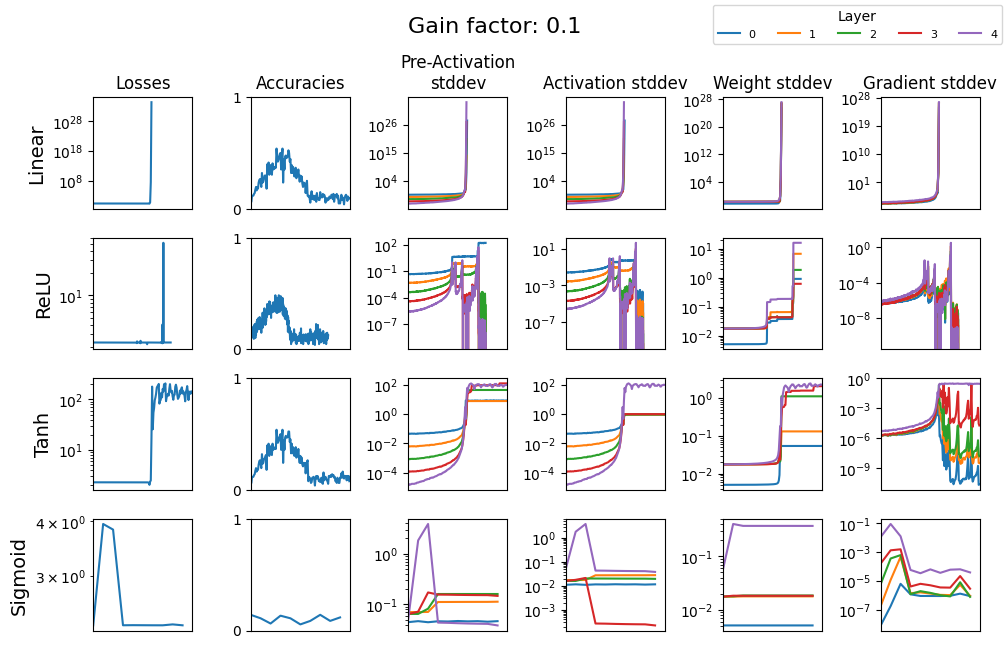

In [12]:
n_plot_linear = 150
n_plot_relu = 600
n_plot_tanh = 150
n_plot_sigmoid = 10
plot_experiments(linear_stats_small, relu_stats_small, tanh_stats_small, sigmoid_stats_small, gain_small,
                    n_plot_linear, n_plot_relu, n_plot_tanh, n_plot_sigmoid)
plt.savefig('training_instability.png')
plt.show()

# Experiment #2: Gain factor 1

In [13]:
gain_med = 1.0
lr = 0.005 * (gain_med)**(-(num_layers - 2))
num_epochs = 5

linear_stats_med = train_model(activation=None, gain=gain_med, num_epochs=num_epochs, lr=lr)
relu_stats_med = train_model(activation=nn.ReLU, gain=gain_med, num_epochs=num_epochs, lr = lr)
tanh_stats_med = train_model(activation=nn.Tanh, gain=gain_med, num_epochs=num_epochs, lr = lr)
sigmoid_stats_med = train_model(activation=nn.Sigmoid, gain=gain_med, num_epochs=num_epochs, lr = lr)

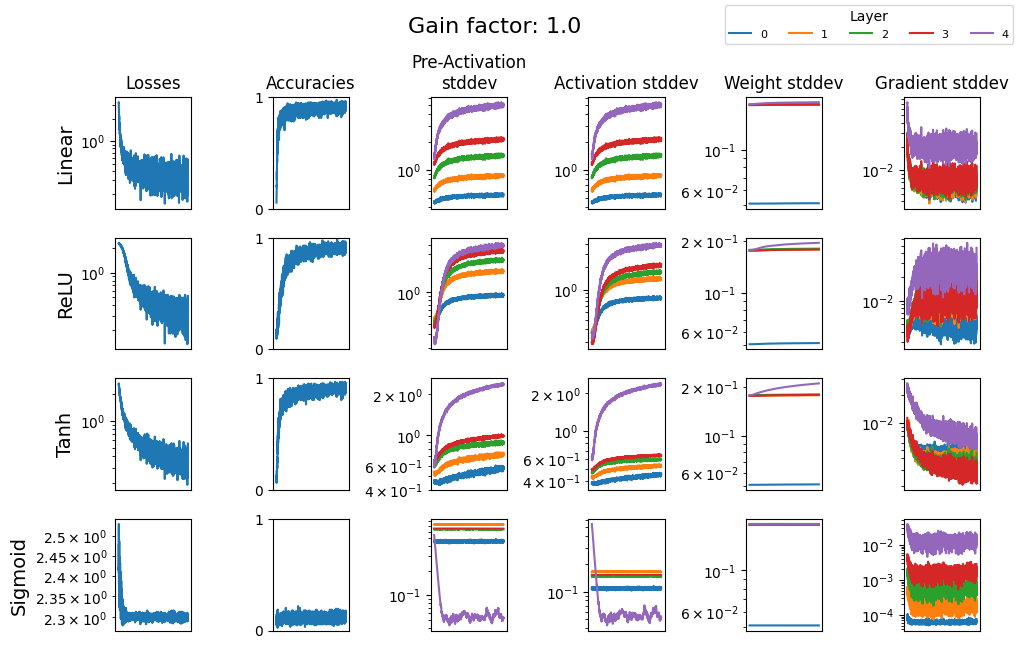

In [14]:

plot_experiments(linear_stats_med, relu_stats_med, tanh_stats_med, sigmoid_stats_med, gain_med)

# Experiment #3: Gain factor 10

In [15]:
gain_large = 10
lr = 0.005 * (gain_large)**(-(num_layers - 2))
num_epochs = 5

linear_stats_large = train_model(activation=None, gain=gain_large, num_epochs = num_epochs, lr=lr)
relu_stats_large = train_model(activation=nn.ReLU, gain=gain_large, num_epochs = num_epochs, lr=lr)
tanh_stats_large = train_model(activation=nn.Tanh, gain=gain_large, num_epochs = num_epochs, lr=lr)
sigmoid_stats_large = train_model(activation=nn.Sigmoid, gain=gain_large, num_epochs = num_epochs, lr=lr)

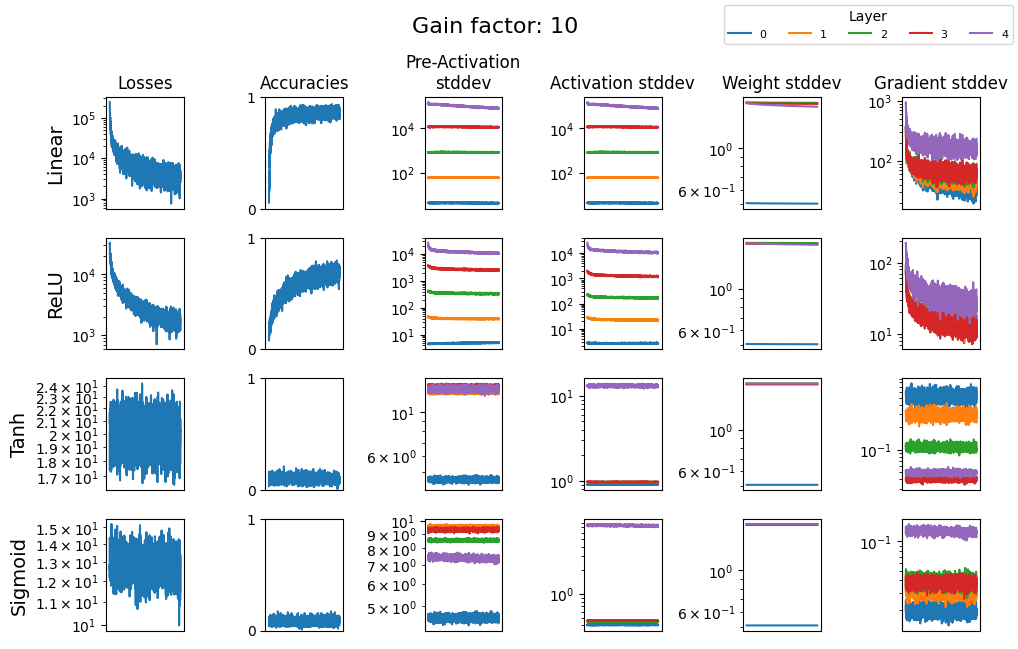

In [16]:
plot_experiments(linear_stats_large, relu_stats_large, tanh_stats_large, sigmoid_stats_large, gain_large)